In [7]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [11]:
import sqlite3

conn = sqlite3.connect("online_retail.db")

df.to_sql(
    "retail",
    conn,
    if_exists="replace",
    index=False
)

print("导入完成")

导入完成


In [12]:
pd.read_sql("""
SELECT COUNT(*) AS row_count
FROM retail;
""", conn)

,row_count
0,541909


In [13]:
pd.read_sql("""
SELECT *
FROM retail
LIMIT 10;
""", conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [14]:
pd.read_sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(CustomerID) AS customer_id_not_null,
    COUNT(Description) AS description_not_null
FROM retail;
""", conn)

,total_rows,customer_id_not_null,description_not_null
0,541909,406829,540455


In [15]:
pd.read_sql("""
SELECT
    MIN(Quantity) AS min_quantity,
    MAX(Quantity) AS max_quantity,
    MIN(UnitPrice) AS min_price,
    MAX(UnitPrice) AS max_price
FROM retail;
""", conn)

,min_quantity,max_quantity,min_price,max_price
0,-80995,80995,-11062.06,38970.0


In [16]:
pd.read_sql("""
SELECT *
FROM retail
WHERE Quantity < 0
LIMIT 20;
""", conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
1,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
2,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
3,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
4,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
5,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
6,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
7,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
8,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
9,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [17]:
pd.read_sql("""
SELECT *
FROM retail
WHERE InvoiceNo LIKE 'C%'
LIMIT 20;
""", conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
1,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
2,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
3,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
4,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
5,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
6,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
7,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
8,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
9,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [18]:
pd.read_sql("""
SELECT COUNT(*) AS negative_quantity_rows
FROM retail
WHERE Quantity < 0;
""", conn)

,negative_quantity_rows
0,10624


In [19]:
pd.read_sql("""
SELECT COUNT(*) AS cancelled_rows
FROM retail
WHERE InvoiceNo LIKE 'C%';
""", conn)

,cancelled_rows
0,9288


In [20]:
pd.read_sql("""
SELECT
    SUM(CASE
        WHEN Quantity < 0 AND InvoiceNo NOT LIKE 'C%'
        THEN 1 ELSE 0
    END) AS negative_but_not_cancelled,

    SUM(CASE
        WHEN Quantity >= 0 AND InvoiceNo LIKE 'C%'
        THEN 1 ELSE 0
    END) AS cancelled_but_not_negative

FROM retail;
""", conn)

,negative_but_not_cancelled,cancelled_but_not_negative
0,1336,0


In [21]:
pd.read_sql("""
SELECT *
FROM retail
WHERE Quantity < 0
  AND InvoiceNo NOT LIKE 'C%'
LIMIT 30;
""", conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536589,21777,None,-10,2010-12-01 16:50:00,0.0,None,United Kingdom
1,536764,84952C,None,-38,2010-12-02 14:42:00,0.0,None,United Kingdom
2,536996,22712,None,-20,2010-12-03 15:30:00,0.0,None,United Kingdom
3,536997,22028,None,-20,2010-12-03 15:30:00,0.0,None,United Kingdom
4,536998,85067,None,-6,2010-12-03 15:30:00,0.0,None,United Kingdom
5,537000,21414,None,-22,2010-12-03 15:32:00,0.0,None,United Kingdom
6,537001,21653,None,-6,2010-12-03 15:33:00,0.0,None,United Kingdom
7,537003,85126,None,-2,2010-12-03 15:33:00,0.0,None,United Kingdom
8,537004,21814,None,-30,2010-12-03 15:34:00,0.0,None,United Kingdom
9,537005,21692,None,-70,2010-12-03 15:35:00,0.0,None,United Kingdom


In [22]:
pd.read_sql("""
SELECT *
FROM retail
WHERE UnitPrice <= 0
ORDER BY UnitPrice
LIMIT 30;
""", conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,None,United Kingdom
1,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,None,United Kingdom
2,536414,22139,None,56,2010-12-01 11:52:00,0.00,None,United Kingdom
3,536545,21134,None,1,2010-12-01 14:32:00,0.00,None,United Kingdom
4,536546,22145,None,1,2010-12-01 14:33:00,0.00,None,United Kingdom
5,536547,37509,None,1,2010-12-01 14:33:00,0.00,None,United Kingdom
6,536549,85226A,None,1,2010-12-01 14:34:00,0.00,None,United Kingdom
7,536550,85044,None,1,2010-12-01 14:34:00,0.00,None,United Kingdom
8,536552,20950,None,1,2010-12-01 14:34:00,0.00,None,United Kingdom
9,536553,37461,None,3,2010-12-01 14:35:00,0.00,None,United Kingdom


In [23]:
pd.read_sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(DISTINCT
        InvoiceNo || '|' ||
        StockCode || '|' ||
        IFNULL(Description, '') || '|' ||
        Quantity || '|' ||
        InvoiceDate || '|' ||
        UnitPrice || '|' ||
        IFNULL(CustomerID, '') || '|' ||
        Country
    ) AS duplicate_rows
FROM retail;
""", conn)

,total_rows,duplicate_rows
0,541909,5268


In [24]:
pd.read_sql("""
SELECT
    InvoiceNo,
    StockCode,
    Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CustomerID,
    Country,
    COUNT(*) AS repeat_count
FROM retail
GROUP BY
    InvoiceNo,
    StockCode,
    Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CustomerID,
    Country
HAVING COUNT(*) > 1
ORDER BY repeat_count DESC
LIMIT 20;
""", conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,repeat_count
0,555524,22698,PINK REGENCY TEACUP AND SAUCER,1,2011-06-05 11:37:00,2.95,16923.0,United Kingdom,20
1,555524,22697,GREEN REGENCY TEACUP AND SAUCER,1,2011-06-05 11:37:00,2.95,16923.0,United Kingdom,12
2,572861,22775,PURPLE DRAWERKNOB ACRYLIC EDWARDIAN,12,2011-10-26 12:46:00,1.25,14102.0,United Kingdom,8
3,538514,21756,BATH BUILDING BLOCK WORD,1,2010-12-12 14:27:00,5.95,15044.0,United Kingdom,6
4,540524,21756,BATH BUILDING BLOCK WORD,1,2011-01-09 12:53:00,5.95,16735.0,United Kingdom,6
5,541266,21754,HOME BUILDING BLOCK WORD,1,2011-01-16 16:25:00,5.95,15673.0,United Kingdom,6
6,541266,21755,LOVE BUILDING BLOCK WORD,1,2011-01-16 16:25:00,5.95,15673.0,United Kingdom,6
7,572344,M,Manual,48,2011-10-24 10:43:00,1.50,14607.0,United Kingdom,6
8,578289,23395,BELLE JARDINIERE CUSHION COVER,1,2011-11-23 14:07:00,3.75,17841.0,United Kingdom,6
9,537224,70007,HI TEC ALPINE HAND WARMER,1,2010-12-05 16:24:00,1.65,13174.0,United Kingdom,5


In [25]:
conn.execute("DROP TABLE IF EXISTS retail_clean")

conn.execute("""
CREATE TABLE retail_clean AS
SELECT DISTINCT *
FROM retail
WHERE Quantity > 0
  AND UnitPrice > 0
  AND InvoiceNo NOT LIKE 'C%'
""")

conn.commit()

print("retail_clean 创建完成")

retail_clean 创建完成


In [26]:
pd.read_sql("""
SELECT
    (SELECT COUNT(*) FROM retail) AS raw_rows,
    (SELECT COUNT(*) FROM retail_clean) AS clean_rows;
""", conn)

,raw_rows,clean_rows
0,541909,524878


In [27]:
pd.read_sql("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN Quantity <= 0 THEN 1 ELSE 0 END) AS invalid_quantity,
    SUM(CASE WHEN UnitPrice <= 0 THEN 1 ELSE 0 END) AS invalid_price,
    SUM(CASE WHEN InvoiceNo LIKE 'C%' THEN 1 ELSE 0 END) AS cancelled_rows
FROM retail_clean;
""", conn)

,total_rows,invalid_quantity,invalid_price,cancelled_rows
0,524878,0,0,0


In [28]:
pd.read_sql("""
SELECT
    ROUND(SUM(Quantity * UnitPrice), 2) AS total_sales,
    COUNT(DISTINCT InvoiceNo) AS total_orders,
    ROUND(
        SUM(Quantity * UnitPrice) / COUNT(DISTINCT InvoiceNo),
        2
    ) AS avg_order_value,
    COUNT(DISTINCT StockCode) AS product_count,
    COUNT(DISTINCT CustomerID) AS customer_count
FROM retail_clean;
""", conn)

,total_sales,total_orders,avg_order_value,product_count,customer_count
0,10642110.8,19960,533.17,3922,4338


In [29]:
pd.read_sql("""
SELECT
    MIN(InvoiceDate) AS start_date,
    MAX(InvoiceDate) AS end_date
FROM retail_clean;
""", conn)

,start_date,end_date
0,2010-12-01 08:26:00,2011-12-09 12:50:00


In [30]:
monthly_sales = pd.read_sql("""
SELECT
    SUBSTR(InvoiceDate, 1, 7) AS month,
    ROUND(SUM(Quantity * UnitPrice), 2) AS sales,
    COUNT(DISTINCT InvoiceNo) AS orders,
    ROUND(
        SUM(Quantity * UnitPrice) / COUNT(DISTINCT InvoiceNo),
        2
    ) AS avg_order_value
FROM retail_clean
GROUP BY SUBSTR(InvoiceDate, 1, 7)
ORDER BY month;
""", conn)

monthly_sales

,month,sales,orders,avg_order_value
0,2010-12,821452.73,1559,526.91
1,2011-01,689811.61,1086,635.19
2,2011-02,522545.56,1100,475.04
3,2011-03,716215.26,1454,492.58
4,2011-04,536968.49,1246,430.95
5,2011-05,769296.61,1681,457.64
6,2011-06,760547.01,1533,496.12
7,2011-07,718076.12,1475,486.83
8,2011-08,757841.38,1361,556.83
9,2011-09,1056435.19,1837,575.09


In [31]:
monthly_growth = pd.read_sql("""
WITH monthly AS (
    SELECT
        SUBSTR(InvoiceDate, 1, 7) AS month,
        SUM(Quantity * UnitPrice) AS sales,
        COUNT(DISTINCT InvoiceNo) AS orders,
        SUM(Quantity * UnitPrice) / COUNT(DISTINCT InvoiceNo) AS avg_order_value
    FROM retail_clean
    GROUP BY SUBSTR(InvoiceDate, 1, 7)
)

SELECT
    month,
    ROUND(sales, 2) AS sales,
    orders,
    ROUND(avg_order_value, 2) AS avg_order_value,

    ROUND(
        (sales - LAG(sales) OVER (ORDER BY month))
        / LAG(sales) OVER (ORDER BY month) * 100,
        2
    ) AS sales_mom_pct,

    ROUND(
        (orders - LAG(orders) OVER (ORDER BY month)) * 100.0
        / LAG(orders) OVER (ORDER BY month),
        2
    ) AS orders_mom_pct,

    ROUND(
        (avg_order_value - LAG(avg_order_value) OVER (ORDER BY month))
        / LAG(avg_order_value) OVER (ORDER BY month) * 100,
        2
    ) AS aov_mom_pct

FROM monthly
ORDER BY month;
""", conn)

monthly_growth

,month,sales,orders,avg_order_value,sales_mom_pct,orders_mom_pct,aov_mom_pct
0,2010-12,821452.73,1559,526.91,NaN,NaN,NaN
1,2011-01,689811.61,1086,635.19,-16.03,-30.34,20.55
2,2011-02,522545.56,1100,475.04,-24.25,1.29,-25.21
3,2011-03,716215.26,1454,492.58,37.06,32.18,3.69
4,2011-04,536968.49,1246,430.95,-25.03,-14.31,-12.51
5,2011-05,769296.61,1681,457.64,43.27,34.91,6.19
6,2011-06,760547.01,1533,496.12,-1.14,-8.80,8.41
7,2011-07,718076.12,1475,486.83,-5.58,-3.78,-1.87
8,2011-08,757841.38,1361,556.83,5.54,-7.73,14.38
9,2011-09,1056435.19,1837,575.09,39.40,34.97,3.28


In [32]:
pd.read_sql("""
SELECT
    MIN(InvoiceDate) AS start_date,
    MAX(InvoiceDate) AS end_date
FROM retail_clean;
""", conn)

,start_date,end_date
0,2010-12-01 08:26:00,2011-12-09 12:50:00


In [33]:
country_monthly = pd.read_sql("""
SELECT
    Country,

    ROUND(SUM(CASE
        WHEN SUBSTR(InvoiceDate, 1, 7) = '2011-08'
        THEN Quantity * UnitPrice ELSE 0
    END), 2) AS sales_aug,

    ROUND(SUM(CASE
        WHEN SUBSTR(InvoiceDate, 1, 7) = '2011-09'
        THEN Quantity * UnitPrice ELSE 0
    END), 2) AS sales_sep,

    ROUND(SUM(CASE
        WHEN SUBSTR(InvoiceDate, 1, 7) = '2011-10'
        THEN Quantity * UnitPrice ELSE 0
    END), 2) AS sales_oct,

    ROUND(SUM(CASE
        WHEN SUBSTR(InvoiceDate, 1, 7) = '2011-11'
        THEN Quantity * UnitPrice ELSE 0
    END), 2) AS sales_nov

FROM retail_clean

WHERE SUBSTR(InvoiceDate, 1, 7)
      BETWEEN '2011-08' AND '2011-11'

GROUP BY Country

ORDER BY sales_nov DESC
LIMIT 15;
""", conn)

country_monthly

,Country,sales_aug,sales_sep,sales_oct,sales_nov
0,United Kingdom,606784.93,895098.64,935404.14,1319934.07
1,France,13810.96,23428.04,33471.05,31696.37
2,EIRE,18344.20,42923.70,24302.92,30713.43
3,Germany,19220.77,18079.47,31628.42,27967.68
4,Netherlands,40327.81,26937.26,40708.65,25874.01
5,Spain,3342.41,5189.24,8636.94,8669.06
6,Japan,0.00,112.08,1948.04,8460.08
7,Switzerland,4969.89,8284.86,8050.73,8118.96
8,Australia,22489.20,5106.73,17150.53,7242.72
9,Norway,2025.81,8678.94,3687.23,6527.50


In [34]:
pd.read_sql("""
SELECT
    Country,
    ROUND(SUM(Quantity * UnitPrice), 2) AS sales,

    ROUND(
        SUM(Quantity * UnitPrice) * 100.0 /
        (
            SELECT SUM(Quantity * UnitPrice)
            FROM retail_clean
            WHERE SUBSTR(InvoiceDate, 1, 7) = '2011-11'
        ),
        2
    ) AS sales_share_pct

FROM retail_clean

WHERE SUBSTR(InvoiceDate, 1, 7) = '2011-11'

GROUP BY Country
ORDER BY sales DESC
LIMIT 15;
""", conn)

,Country,sales,sales_share_pct
0,United Kingdom,1319934.07,87.77
1,France,31696.37,2.11
2,EIRE,30713.43,2.04
3,Germany,27967.68,1.86
4,Netherlands,25874.01,1.72
5,Spain,8669.06,0.58
6,Japan,8460.08,0.56
7,Switzerland,8118.96,0.54
8,Australia,7242.72,0.48
9,Norway,6527.50,0.43


In [35]:
top_products_nov = pd.read_sql("""
SELECT
    StockCode,
    Description,
    SUM(Quantity) AS quantity_sold,
    ROUND(SUM(Quantity * UnitPrice), 2) AS sales
FROM retail_clean
WHERE Country = 'United Kingdom'
  AND SUBSTR(InvoiceDate, 1, 7) = '2011-11'
GROUP BY StockCode, Description
ORDER BY sales DESC
LIMIT 20;
""", conn)

top_products_nov

,StockCode,Description,quantity_sold,sales
0,DOT,DOTCOM POSTAGE,47,36905.40
1,22086,PAPER CHAIN KIT 50'S CHRISTMAS,7629,28225.99
2,23084,RABBIT NIGHT LIGHT,8675,23159.84
3,22197,POPCORN HOLDER,12030,13856.10
4,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,3783,12814.69
5,85123A,WHITE HANGING HEART T-LIGHT HOLDER,4246,12395.50
6,79321,CHILLI LIGHTS,2084,11439.77
7,23355,HOT WATER BOTTLE KEEP CALM,2264,11377.72
8,85099B,JUMBO BAG RED RETROSPOT,5571,10996.33
9,22423,REGENCY CAKESTAND 3 TIER,814,10955.58


In [36]:
product_growth = pd.read_sql("""
WITH product_monthly AS (
    SELECT
        StockCode,
        Description,

        SUM(CASE
            WHEN SUBSTR(InvoiceDate, 1, 7) = '2011-10'
            THEN Quantity * UnitPrice
            ELSE 0
        END) AS sales_oct,

        SUM(CASE
            WHEN SUBSTR(InvoiceDate, 1, 7) = '2011-11'
            THEN Quantity * UnitPrice
            ELSE 0
        END) AS sales_nov

    FROM retail_clean
    WHERE Country = 'United Kingdom'
      AND SUBSTR(InvoiceDate, 1, 7) IN ('2011-10', '2011-11')

    GROUP BY StockCode, Description
)

SELECT
    StockCode,
    Description,
    ROUND(sales_oct, 2) AS sales_oct,
    ROUND(sales_nov, 2) AS sales_nov,
    ROUND(sales_nov - sales_oct, 2) AS sales_increase
FROM product_monthly
ORDER BY sales_increase DESC
LIMIT 20;
""", conn)

product_growth

,StockCode,Description,sales_oct,sales_nov,sales_increase
0,23084,RABBIT NIGHT LIGHT,3613.27,23159.84,19546.57
1,DOT,DOTCOM POSTAGE,17955.13,36905.40,18950.27
2,22086,PAPER CHAIN KIT 50'S CHRISTMAS,9743.54,28225.99,18482.45
3,22197,POPCORN HOLDER,4263.80,13856.10,9592.30
4,85123A,WHITE HANGING HEART T-LIGHT HOLDER,4046.50,12395.50,8349.00
5,22910,PAPER CHAIN KIT VINTAGE CHRISTMAS,4727.77,12814.69,8086.92
6,79321,CHILLI LIGHTS,4655.13,11439.77,6784.64
7,23344,JUMBO BAG 50'S CHRISTMAS,4266.87,10848.74,6581.87
8,21137,BLACK RECORD COVER FRAME,2196.72,7794.80,5598.08
9,23581,JUMBO BAG PAISLEY PARK,2026.76,7520.42,5493.66


In [37]:
pd.read_sql("""
SELECT
    ROUND(SUM(CASE
        WHEN CustomerID IS NULL
        THEN Quantity * UnitPrice ELSE 0
    END), 2) AS anonymous_sales,

    ROUND(SUM(CASE
        WHEN CustomerID IS NOT NULL
        THEN Quantity * UnitPrice ELSE 0
    END), 2) AS identified_sales,

    ROUND(
        SUM(CASE
            WHEN CustomerID IS NULL
            THEN Quantity * UnitPrice ELSE 0
        END) * 100.0
        / SUM(Quantity * UnitPrice),
        2
    ) AS anonymous_share_pct

FROM retail_clean
WHERE Country = 'United Kingdom'
  AND SUBSTR(InvoiceDate, 1, 7) = '2011-11';
""", conn)

,anonymous_sales,identified_sales,anonymous_share_pct
0,344682.68,975251.39,26.11


In [38]:
top_customers_nov = pd.read_sql("""
SELECT
    CustomerID,
    COUNT(DISTINCT InvoiceNo) AS orders,
    ROUND(SUM(Quantity * UnitPrice), 2) AS sales
FROM retail_clean
WHERE Country = 'United Kingdom'
  AND CustomerID IS NOT NULL
  AND SUBSTR(InvoiceDate, 1, 7) = '2011-11'
GROUP BY CustomerID
ORDER BY sales DESC
LIMIT 20;
""", conn)

top_customers_nov

,CustomerID,orders,sales
0,17450.0,10,27869.45
1,14096.0,4,27827.78
2,14088.0,5,16851.61
3,18102.0,6,15331.08
4,17511.0,3,13522.22
5,17389.0,5,12361.36
6,12748.0,45,10453.69
7,13081.0,3,9467.26
8,18139.0,6,8438.34
9,15482.0,5,8191.46


In [39]:
customer_growth = pd.read_sql("""
WITH customer_monthly AS (
    SELECT
        CustomerID,

        SUM(CASE
            WHEN SUBSTR(InvoiceDate, 1, 7) = '2011-10'
            THEN Quantity * UnitPrice ELSE 0
        END) AS sales_oct,

        SUM(CASE
            WHEN SUBSTR(InvoiceDate, 1, 7) = '2011-11'
            THEN Quantity * UnitPrice ELSE 0
        END) AS sales_nov

    FROM retail_clean
    WHERE Country = 'United Kingdom'
      AND CustomerID IS NOT NULL
      AND SUBSTR(InvoiceDate, 1, 7) IN ('2011-10', '2011-11')

    GROUP BY CustomerID
)

SELECT
    CustomerID,
    ROUND(sales_oct, 2) AS sales_oct,
    ROUND(sales_nov, 2) AS sales_nov,
    ROUND(sales_nov - sales_oct, 2) AS sales_increase
FROM customer_monthly
ORDER BY sales_increase DESC
LIMIT 20;
""", conn)

customer_growth

,CustomerID,sales_oct,sales_nov,sales_increase
0,17450.0,3935.96,27869.45,23933.49
1,17389.0,0.00,12361.36,12361.36
2,13081.0,0.00,9467.26,9467.26
3,14088.0,8132.31,16851.61,8719.30
4,14096.0,19114.33,27827.78,8713.45
5,18139.0,0.00,8438.34,8438.34
6,12748.0,2199.30,10453.69,8254.39
7,17511.0,5755.45,13522.22,7766.77
8,15482.0,760.00,8191.46,7431.46
9,12931.0,1909.36,7615.90,5706.54


In [40]:
clean_df = pd.read_sql("""
SELECT *
FROM retail_clean
""", conn)

clean_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [41]:
clean_df["Sales"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

clean_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [42]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524878 non-null  object 
 1   StockCode    524878 non-null  object 
 2   Description  524878 non-null  object 
 3   Quantity     524878 non-null  int64  
 4   InvoiceDate  524878 non-null  object 
 5   UnitPrice    524878 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      524878 non-null  object 
 8   Sales        524878 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 36.0+ MB


In [43]:
clean_df["Sales"].describe()

,Sales
count,524878.000000
mean,20.275399
std,271.693566
min,0.001000
25%,3.900000
50%,9.920000
75%,17.700000
max,168469.600000


In [44]:
clean_df.sort_values(
    "Sales",
    ascending=False
)[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Sales",
        "CustomerID",
        "Country"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Sales,CustomerID,Country
523404,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
59649,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
215474,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,United Kingdom
14456,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,NaN,United Kingdom
290506,A563185,B,Adjust bad debt,1,11062.06,11062.06,NaN,United Kingdom
167609,551697,POST,POSTAGE,1,8142.75,8142.75,16029.0,United Kingdom
337516,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0,United Kingdom
155191,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
50902,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
408207,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0,Netherlands


In [45]:
check_cancel = df[
    df["InvoiceNo"].astype(str).isin(
        ["581483", "C581484", "541431", "C541433"]
    )
][[
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID"
]].sort_values("InvoiceDate")

check_cancel

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0


In [46]:
clean_df["InvoiceDate"] = pd.to_datetime(
    clean_df["InvoiceDate"]
)

clean_df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [47]:
special_items = clean_df[
    clean_df["StockCode"]
    .astype(str)
    .str.contains(r"[A-Za-z]", regex=True)
][[
    "StockCode",
    "Description"
]].drop_duplicates()

special_items.sort_values("StockCode")

,StockCode,Description
5274,10123C,HEARTS WRAPPING TAPE
12080,10124A,SPOTS ON RED BOOKCOVER TAPE
3878,10124G,ARMY CAMO BOOKCOVER TAPE
38760,15044A,PINK PAPER PARASOL
1061,15044B,BLUE PAPER PARASOL
...,...,...
43227,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00
43158,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00
36967,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00
40570,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00


In [48]:
txn_df = df.copy()

# 去除完全重复记录
txn_df = txn_df.drop_duplicates()

# 数据类型
txn_df["InvoiceNo"] = txn_df["InvoiceNo"].astype(str)
txn_df["InvoiceDate"] = pd.to_datetime(txn_df["InvoiceDate"])

# 每行交易金额
# 取消/退货记录 Quantity 为负，因此金额自动为负
txn_df["Sales"] = txn_df["Quantity"] * txn_df["UnitPrice"]

txn_df.shape

(536641, 9)

In [49]:
non_product_codes = [
    "POST",          # Postage
    "DOT",           # Dotcom postage
    "M",             # Manual
    "D",             # Discount
    "AMAZONFEE",     # Amazon fee
    "BANK CHARGES",
    "B",             # Bad debt
    "CRUK",
    "C2"
]

In [50]:
product_txn = txn_df[
    (txn_df["UnitPrice"] > 0) &
    (~txn_df["StockCode"].astype(str).isin(non_product_codes))
].copy()

product_txn.shape

(531302, 9)

In [51]:
product_txn[
    product_txn["InvoiceNo"].isin(
        ["541431", "C541433", "581483", "C581484"]
    )
][
    ["InvoiceNo", "StockCode", "Quantity",
     "UnitPrice", "Sales", "CustomerID"]
]

,InvoiceNo,StockCode,Quantity,UnitPrice,Sales,CustomerID
61619,541431,23166,74215,1.04,77183.6,12346.0
61624,C541433,23166,-74215,1.04,-77183.6,12346.0
540421,581483,23843,80995,2.08,168469.6,16446.0
540422,C581484,23843,-80995,2.08,-168469.6,16446.0


In [52]:
product_txn[
    product_txn["InvoiceNo"].isin(
        ["541431", "C541433", "581483", "C581484"]
    )
]["Sales"].sum()

np.float64(0.0)

In [53]:
product_txn["Sales"].describe()

,Sales
count,531302.000000
mean,18.386844
std,369.724269
min,-168469.600000
25%,3.750000
50%,9.900000
75%,17.400000
max,168469.600000


In [54]:
product_txn[
    product_txn["Sales"] > 0
].sort_values(
    "Sales",
    ascending=False
)[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Sales",
        "CustomerID",
        "Country"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Sales,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0,United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0,United Kingdom
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0,United Kingdom
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0,Netherlands
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,4921.50,15749.0,United Kingdom
467804,576365,22086,PAPER CHAIN KIT 50'S CHRISTMAS,688,6.95,4781.60,NaN,United Kingdom
160542,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.40,4632.00,15749.0,United Kingdom


In [55]:
gross_sales = product_txn.loc[
    product_txn["Sales"] > 0, "Sales"
].sum()

cancelled_sales = -product_txn.loc[
    product_txn["Sales"] < 0, "Sales"
].sum()

net_sales = product_txn["Sales"].sum()

cancel_rate = cancelled_sales / gross_sales * 100

print(f"Gross Sales: £{gross_sales:,.2f}")
print(f"Cancelled/Returned: £{cancelled_sales:,.2f}")
print(f"Net Sales: £{net_sales:,.2f}")
print(f"Cancellation Rate: {cancel_rate:.2f}%")

Gross Sales: £10,247,970.73
Cancelled/Returned: £479,003.86
Net Sales: £9,768,966.87
Cancellation Rate: 4.67%


In [56]:
product_net_sales = (
    product_txn
    .groupby(
        ["StockCode", "Description"],
        as_index=False
    )
    .agg(
        net_quantity=("Quantity", "sum"),
        net_sales=("Sales", "sum")
    )
    .sort_values(
        "net_sales",
        ascending=False
    )
)

product_net_sales.head(20)

,StockCode,Description,net_quantity,net_sales
1265,22423,REGENCY CAKESTAND 3 TIER,12996,164459.49
2674,47566,PARTY BUNTING,18006,98243.88
3787,85123A,WHITE HANGING HEART T-LIGHT HOLDER,35002,97659.94
3775,85099B,JUMBO BAG RED RETROSPOT,47256,92175.79
1954,23084,RABBIT NIGHT LIGHT,30631,66661.63
947,22086,PAPER CHAIN KIT 50'S CHRISTMAS,18876,63715.24
2882,84879,ASSORTED COLOUR BIRD ORNAMENT,36282,58792.42
2743,79321,CHILLI LIGHTS,10222,53746.66
2210,23298,SPOTTY BUNTING,8210,42030.67
1232,22386,JUMBO BAG PINK POLKADOT,20992,41584.43


In [57]:
product_txn["Month"] = (
    product_txn["InvoiceDate"]
    .dt.to_period("M")
    .astype(str)
)

monthly_net = (
    product_txn
    .groupby("Month", as_index=False)
    .agg(
        net_sales=("Sales", "sum")
    )
)

monthly_net

,Month,net_sales
0,2010-12,758104.690
1,2011-01,578914.410
2,2011-02,498722.340
3,2011-03,679220.700
4,2011-04,482183.601
5,2011-05,730668.550
6,2011-06,723344.640
7,2011-07,676845.411
8,2011-08,700582.390
9,2011-09,1011364.741


In [58]:
monthly_summary = (
    product_txn
    .assign(
        GrossSales=product_txn["Sales"].clip(lower=0),
        CancelledSales=(-product_txn["Sales"].clip(upper=0))
    )
    .groupby("Month", as_index=False)
    .agg(
        gross_sales=("GrossSales", "sum"),
        cancelled_sales=("CancelledSales", "sum"),
        net_sales=("Sales", "sum")
    )
)

monthly_summary

,Month,gross_sales,cancelled_sales,net_sales
0,2010-12,775717.500,17612.81,758104.690
1,2011-01,670439.460,91525.05,578914.410
2,2011-02,507866.540,9144.20,498722.340
3,2011-03,689841.840,10621.14,679220.700
4,2011-04,515499.661,33316.06,482183.601
5,2011-05,740036.330,9367.78,730668.550
6,2011-06,737683.990,14339.35,723344.640
7,2011-07,688252.671,11407.26,676845.411
8,2011-08,724308.160,23725.77,700582.390
9,2011-09,1028345.381,16980.64,1011364.741


In [59]:
monthly_summary["cancel_rate_pct"] = (
    monthly_summary["cancelled_sales"]
    / monthly_summary["gross_sales"]
    * 100
)

monthly_summary[
    [
        "Month",
        "gross_sales",
        "cancelled_sales",
        "net_sales",
        "cancel_rate_pct"
    ]
]

,Month,gross_sales,cancelled_sales,net_sales,cancel_rate_pct
0,2010-12,775717.500,17612.81,758104.690,2.270519
1,2011-01,670439.460,91525.05,578914.410,13.651501
2,2011-02,507866.540,9144.20,498722.340,1.800512
3,2011-03,689841.840,10621.14,679220.700,1.539649
4,2011-04,515499.661,33316.06,482183.601,6.462867
5,2011-05,740036.330,9367.78,730668.550,1.265854
6,2011-06,737683.990,14339.35,723344.640,1.943834
7,2011-07,688252.671,11407.26,676845.411,1.657423
8,2011-08,724308.160,23725.77,700582.390,3.275646
9,2011-09,1028345.381,16980.64,1011364.741,1.651258


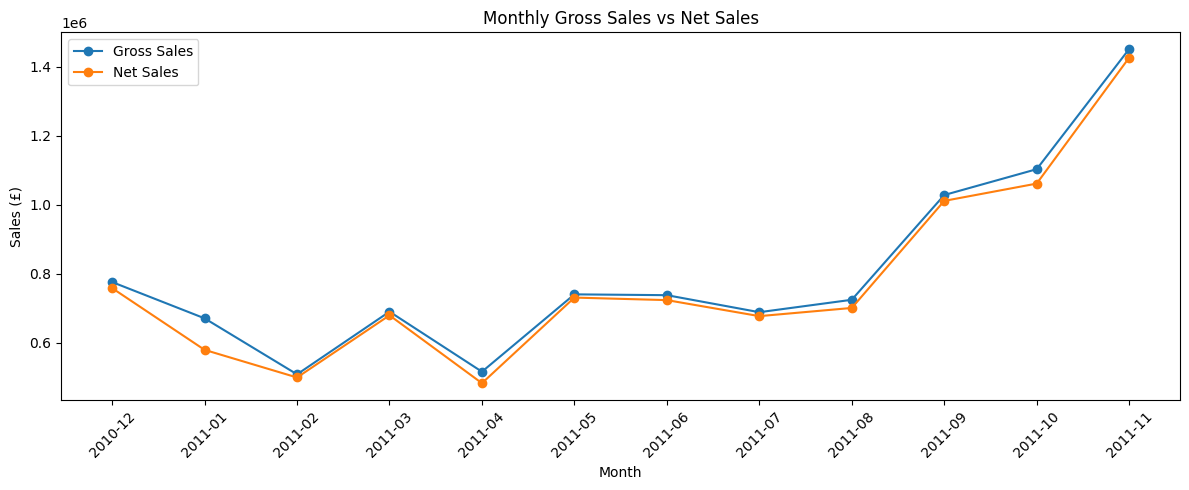

In [60]:
import matplotlib.pyplot as plt

plot_df = monthly_summary[
    monthly_summary["Month"] != "2011-12"
].copy()

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["Month"],
    plot_df["gross_sales"],
    marker="o",
    label="Gross Sales"
)

plt.plot(
    plot_df["Month"],
    plot_df["net_sales"],
    marker="o",
    label="Net Sales"
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Sales (£)")
plt.title("Monthly Gross Sales vs Net Sales")
plt.legend()
plt.tight_layout()
plt.show()

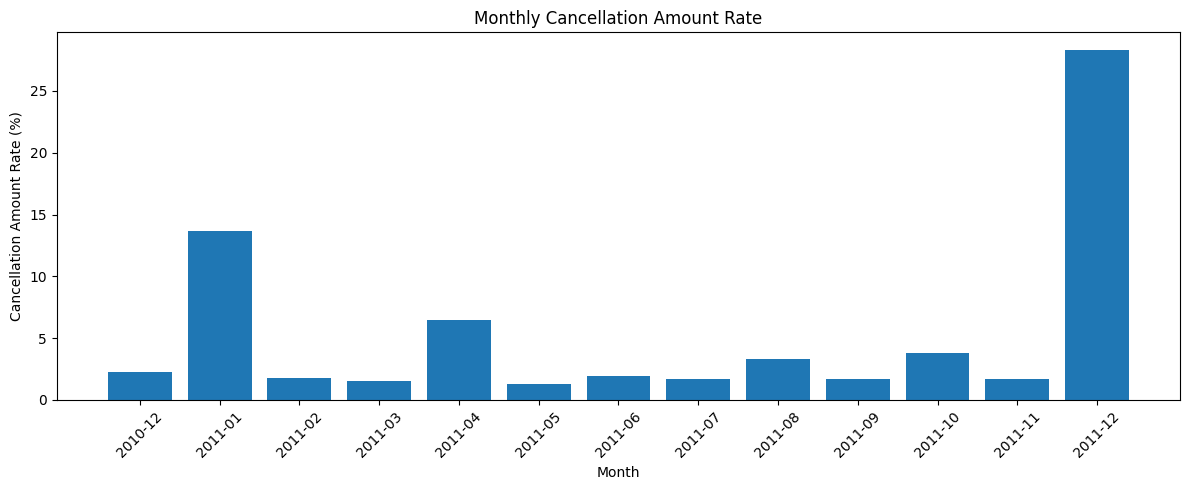

In [61]:
plt.figure(figsize=(12, 5))

plt.bar(
    monthly_summary["Month"],
    monthly_summary["cancel_rate_pct"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Cancellation Amount Rate (%)")
plt.title("Monthly Cancellation Amount Rate")
plt.tight_layout()
plt.show()

In [62]:
purchase_df = product_txn[
    (product_txn["Quantity"] > 0) &
    (product_txn["CustomerID"].notna())
].copy()

In [63]:
customer_orders = (
    purchase_df
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index(name="order_count")
)

customer_orders.head()

,CustomerID,order_count
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [64]:
customer_orders["order_count"].describe()

,order_count
count,4334.000000
mean,4.245962
std,7.634989
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,206.000000


In [65]:
total_customers = customer_orders["CustomerID"].nunique()

repeat_customers = (
    customer_orders["order_count"] >= 2
).sum()

repeat_rate = (
    repeat_customers / total_customers * 100
)

print(f"Total Customers: {total_customers:,}")
print(f"Repeat Customers: {repeat_customers:,}")
print(f"Repeat Purchase Rate: {repeat_rate:.2f}%")

Total Customers: 4,334
Repeat Customers: 2,829
Repeat Purchase Rate: 65.27%


In [66]:
customer_value = (
    purchase_df
    .groupby("CustomerID")
    .agg(
        orders=("InvoiceNo", "nunique"),
        monetary=("Sales", "sum")
    )
    .reset_index()
)

customer_value.head()

,CustomerID,orders,monetary
0,12346.0,1,77183.60
1,12347.0,7,4310.00
2,12348.0,4,1437.24
3,12349.0,1,1457.55
4,12350.0,1,294.40


In [67]:
customer_value[["orders", "monetary"]].describe()

,orders,monetary
count,4334.000000,4334.000000
mean,4.245962,2015.973153
std,7.634989,8903.673825
min,1.000000,3.750000
25%,1.000000,304.240000
50%,2.000000,662.565000
75%,5.000000,1631.622500
max,206.000000,279138.020000


In [68]:
customer_value = customer_value.sort_values(
    "monetary",
    ascending=False
).reset_index(drop=True)

top_10_n = int(len(customer_value) * 0.10)

top_10_sales = customer_value.iloc[:top_10_n]["monetary"].sum()
total_customer_sales = customer_value["monetary"].sum()

top_10_share = top_10_sales / total_customer_sales * 100

print(f"Top 10% Customers: {top_10_n}")
print(f"Top 10% Sales: £{top_10_sales:,.2f}")
print(f"Total Customer Sales: £{total_customer_sales:,.2f}")
print(f"Top 10% Sales Contribution: {top_10_share:.2f}%")

Top 10% Customers: 433
Top 10% Sales: £5,362,453.87
Total Customer Sales: £8,737,227.64
Top 10% Sales Contribution: 61.37%


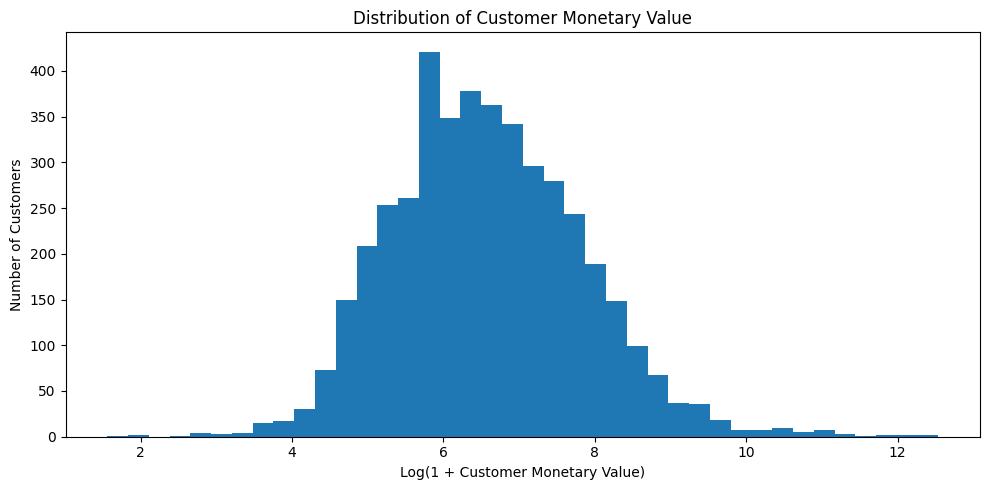

In [69]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(customer_value["monetary"]),
    bins=40
)

plt.xlabel("Log(1 + Customer Monetary Value)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Monetary Value")
plt.tight_layout()
plt.show()

In [70]:
analysis_date = (
    purchase_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

print("Analysis Date:", analysis_date)

Analysis Date: 2011-12-10 12:50:00


In [71]:
rfm = (
    purchase_df
    .groupby("CustomerID")
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Sales", "sum")
    )
    .reset_index()
)

rfm["Recency"] = (
    analysis_date - rfm["LastPurchase"]
).dt.days

rfm = rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1437.24
3,12349.0,19,1,1457.55
4,12350.0,310,1,294.40


In [72]:
rfm[
    ["Recency", "Frequency", "Monetary"]
].describe()

,Recency,Frequency,Monetary
count,4334.000000,4334.000000,4334.000000
mean,92.703046,4.245962,2015.973153
std,100.177047,7.634989,8903.673825
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,304.240000
50%,51.000000,2.000000,662.565000
75%,143.000000,5.000000,1631.622500
max,374.000000,206.000000,279138.020000


In [73]:
# 客户净消费额：正向销售和取消/退货一起计算
customer_net = (
    product_txn[
        product_txn["CustomerID"].notna()
    ]
    .groupby("CustomerID", as_index=False)
    .agg(
        Monetary=("Sales", "sum")
    )
)

# 客户购买行为：只看正向购买订单
purchase_behavior = (
    product_txn[
        (product_txn["Quantity"] > 0) &
        (product_txn["CustomerID"].notna())
    ]
    .groupby("CustomerID", as_index=False)
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique")
    )
)

rfm = purchase_behavior.merge(
    customer_net,
    on="CustomerID",
    how="left"
)

analysis_date = (
    product_txn["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

rfm["Recency"] = (
    analysis_date - rfm["LastPurchase"]
).dt.days

rfm = rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

# 净消费 <= 0 的客户不进入价值分层
rfm = rfm[
    rfm["Monetary"] > 0
].copy()

rfm["CustomerID"] = (
    rfm["CustomerID"].astype(int)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,19,1,1457.55
4,12350,310,1,294.40
5,12352,36,7,1265.41


In [74]:
customer_net[
    customer_net["CustomerID"].isin(
        [12346, 16446]
    )
]

,CustomerID,Monetary
0,12346.0,0.0
3026,16446.0,2.9


In [75]:
customer_value_net = (
    rfm[
        ["CustomerID", "Frequency", "Monetary"]
    ]
    .sort_values(
        "Monetary",
        ascending=False
    )
    .reset_index(drop=True)
)

top_10_n = int(
    len(customer_value_net) * 0.10
)

top_10_sales = (
    customer_value_net
    .iloc[:top_10_n]["Monetary"]
    .sum()
)

total_customer_sales = (
    customer_value_net["Monetary"].sum()
)

top_10_share = (
    top_10_sales
    / total_customer_sales
    * 100
)

print(f"Customers in RFM: {len(customer_value_net):,}")
print(f"Top 10% Customers: {top_10_n:,}")
print(f"Top 10% Net Sales: £{top_10_sales:,.2f}")
print(f"Total Customer Net Sales: £{total_customer_sales:,.2f}")
print(f"Top 10% Net Sales Contribution: {top_10_share:.2f}%")

Customers in RFM: 4,325
Top 10% Customers: 432
Top 10% Net Sales: £4,971,878.23
Total Customer Net Sales: £8,269,637.32
Top 10% Net Sales Contribution: 60.12%


In [76]:
rfm[
    ["Recency", "Frequency", "Monetary"]
].describe()

,Recency,Frequency,Monetary
count,4325.000000,4325.000000,4.325000e+03
mean,92.528324,4.252254,1.912055e+03
std,100.096156,7.641659,8.299237e+03
min,1.000000,1.000000,1.776357e-15
25%,18.000000,1.000000,2.982100e+02
50%,51.000000,2.000000,6.484100e+02
75%,143.000000,5.000000,1.607060e+03
max,374.000000,206.000000,2.787780e+05


In [77]:
import numpy as np

# R：越近越好，所以 Recency 越小得分越高
r_pct = rfm["Recency"].rank(
    method="average",
    pct=True,
    ascending=True
)

rfm["R_Score"] = (
    6 - np.ceil(r_pct * 5)
).clip(1, 5).astype(int)

# F：购买次数越多越好
f_pct = rfm["Frequency"].rank(
    method="average",
    pct=True,
    ascending=True
)

rfm["F_Score"] = (
    np.ceil(f_pct * 5)
).clip(1, 5).astype(int)

# M：净消费额越高越好
m_pct = rfm["Monetary"].rank(
    method="average",
    pct=True,
    ascending=True
)

rfm["M_Score"] = (
    np.ceil(m_pct * 5)
).clip(1, 5).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
1,12347,2,7,4310.00,5,5,5,15
2,12348,75,4,1437.24,2,4,4,10
3,12349,19,1,1457.55,4,1,4,9
4,12350,310,1,294.40,1,1,2,4
5,12352,36,7,1265.41,3,5,4,12
6,12353,204,1,89.00,1,1,1,3
7,12354,232,1,1079.40,1,1,4,6
8,12355,214,1,459.40,1,1,2,4
9,12356,23,3,2487.43,4,3,5,12
10,12357,33,1,6207.67,3,1,5,9


In [78]:
rfm["Monetary"] = rfm["Monetary"].round(2)

rfm = rfm[
    rfm["Monetary"] > 0
].copy()

print("RFM Customers:", len(rfm))

RFM Customers: 4320


In [79]:
import numpy as np

# R：最近购买越近越好，所以 Recency 越小，得分越高
r_pct = rfm["Recency"].rank(
    method="average",
    pct=True,
    ascending=True
)

rfm["R_Score"] = (
    6 - np.ceil(r_pct * 5)
).clip(1, 5).astype(int)


# F：购买次数越多越好
f_pct = rfm["Frequency"].rank(
    method="average",
    pct=True,
    ascending=True
)

rfm["F_Score"] = (
    np.ceil(f_pct * 5)
).clip(1, 5).astype(int)


# M：净消费金额越高越好
m_pct = rfm["Monetary"].rank(
    method="average",
    pct=True,
    ascending=True
)

rfm["M_Score"] = (
    np.ceil(m_pct * 5)
).clip(1, 5).astype(int)


rfm["RFM_Score"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
1,12347,2,7,4310.00,5,5,5,15
2,12348,75,4,1437.24,2,4,4,10
3,12349,19,1,1457.55,4,1,4,9
4,12350,310,1,294.40,1,1,2,4
5,12352,36,7,1265.41,3,5,4,12
6,12353,204,1,89.00,1,1,1,3
7,12354,232,1,1079.40,1,1,4,6
8,12355,214,1,459.40,1,1,2,4
9,12356,23,3,2487.43,4,3,5,12
10,12357,33,1,6207.67,3,1,5,9


In [80]:
conditions = [

    # 1. 高价值核心客户
    (
        (rfm["R_Score"] >= 4) &
        (rfm["F_Score"] >= 4) &
        (rfm["M_Score"] >= 4)
    ),

    # 2. 流失风险客户：
    # 以前买得多、花得多，但已经很久没来了
    (
        (rfm["R_Score"] <= 2) &
        (rfm["F_Score"] >= 3) &
        (rfm["M_Score"] >= 3)
    ),

    # 3. 忠诚客户
    (
        (rfm["R_Score"] >= 3) &
        (rfm["F_Score"] >= 4)
    ),

    # 4. 潜力客户
    (
        (rfm["R_Score"] >= 4) &
        (rfm["F_Score"].between(2, 3))
    ),

    # 5. 新客户
    (
        (rfm["R_Score"] >= 4) &
        (rfm["F_Score"] == 1)
    ),

    # 6. 沉睡客户
    (
        (rfm["R_Score"] <= 2) &
        (rfm["F_Score"] <= 2)
    )
]

labels = [
    "High Value",
    "At Risk",
    "Loyal",
    "Potential",
    "New",
    "Hibernating"
]

rfm["Segment"] = np.select(
    conditions,
    labels,
    default="Regular"
)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
1,12347,2,7,4310.00,5,5,5,15,High Value
2,12348,75,4,1437.24,2,4,4,10,At Risk
3,12349,19,1,1457.55,4,1,4,9,New
4,12350,310,1,294.40,1,1,2,4,Hibernating
5,12352,36,7,1265.41,3,5,4,12,Loyal
6,12353,204,1,89.00,1,1,1,3,Hibernating
7,12354,232,1,1079.40,1,1,4,6,Hibernating
8,12355,214,1,459.40,1,1,2,4,Hibernating
9,12356,23,3,2487.43,4,3,5,12,Potential
10,12357,33,1,6207.67,3,1,5,9,Regular


In [81]:
segment_summary = (
    rfm
    .groupby("Segment")
    .agg(
        customers=("CustomerID", "count"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean"),
        total_monetary=("Monetary", "sum")
    )
    .reset_index()
)

segment_summary["customer_share_pct"] = (
    segment_summary["customers"]
    / segment_summary["customers"].sum()
    * 100
)

segment_summary["sales_share_pct"] = (
    segment_summary["total_monetary"]
    / segment_summary["total_monetary"].sum()
    * 100
)

segment_summary = segment_summary.sort_values(
    "total_monetary",
    ascending=False
)

segment_summary.round(2)

,Segment,customers,avg_recency,avg_frequency,avg_monetary,total_monetary,customer_share_pct,sales_share_pct
2,High Value,899,12.14,11.50,6044.78,5434256.18,20.81,65.71
3,Loyal,388,38.79,5.76,2042.80,792606.46,8.98,9.58
0,At Risk,528,141.60,3.56,1483.07,783059.55,12.22,9.47
6,Regular,827,87.83,1.90,529.90,438227.32,19.14,5.30
5,Potential,480,16.28,2.42,834.88,400742.50,11.11,4.85
1,Hibernating,966,221.87,1.00,359.79,347556.01,22.36,4.20
4,New,232,18.56,1.00,315.47,73189.30,5.37,0.89


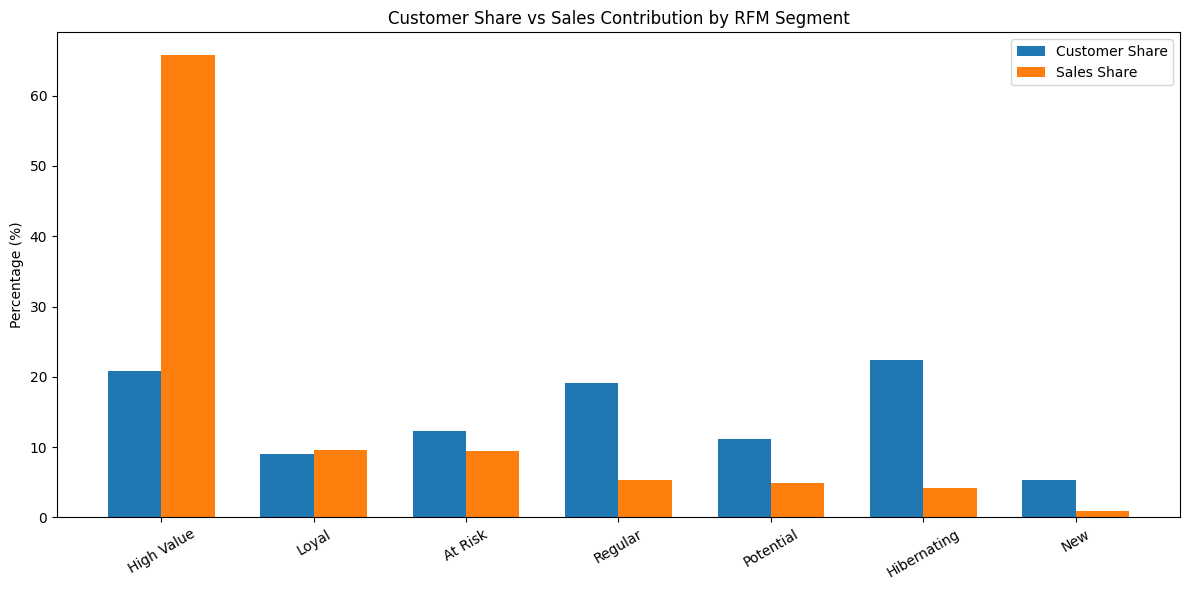

In [82]:
import matplotlib.pyplot as plt
import numpy as np

plot_seg = segment_summary.sort_values(
    "sales_share_pct",
    ascending=False
).copy()

x = np.arange(len(plot_seg))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    plot_seg["customer_share_pct"],
    width,
    label="Customer Share"
)

plt.bar(
    x + width / 2,
    plot_seg["sales_share_pct"],
    width,
    label="Sales Share"
)

plt.xticks(
    x,
    plot_seg["Segment"],
    rotation=30
)

plt.ylabel("Percentage (%)")
plt.title("Customer Share vs Sales Contribution by RFM Segment")
plt.legend()
plt.tight_layout()
plt.show()

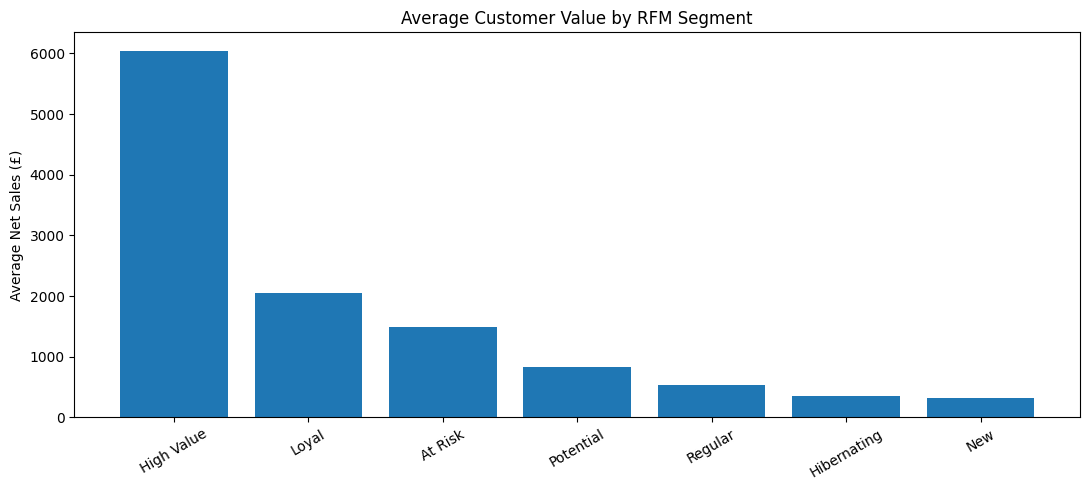

In [83]:
plot_value = segment_summary.sort_values(
    "avg_monetary",
    ascending=False
)

plt.figure(figsize=(11, 5))

plt.bar(
    plot_value["Segment"],
    plot_value["avg_monetary"]
)

plt.xticks(rotation=30)
plt.ylabel("Average Net Sales (£)")
plt.title("Average Customer Value by RFM Segment")
plt.tight_layout()
plt.show()

In [84]:
# 1. 月度经营数据
monthly_summary.to_csv(
    "monthly_summary.csv",
    index=False
)

# 2. RFM 客户分群
rfm.to_csv(
    "rfm_segments.csv",
    index=False
)

# 3. 商品净销售排名
product_net_sales.to_csv(
    "product_net_sales.csv",
    index=False
)

# 4. 商品交易明细
product_txn.to_csv(
    "retail_transactions.csv",
    index=False
)

print("Power BI 数据文件导出完成")

Power BI 数据文件导出完成


In [85]:
with pd.ExcelWriter(
    "powerbi_retail_project.xlsx",
    engine="openpyxl"
) as writer:

    monthly_summary.to_excel(
        writer,
        sheet_name="Monthly_Summary",
        index=False
    )

    product_net_sales.to_excel(
        writer,
        sheet_name="Product_Sales",
        index=False
    )

    rfm.to_excel(
        writer,
        sheet_name="RFM_Customers",
        index=False
    )

    product_txn.to_excel(
        writer,
        sheet_name="Transactions",
        index=False
    )

print("Power BI Excel 文件生成完成")

Power BI Excel 文件生成完成
